# Part 1: Data Quality & Preprocessing

In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.tsa.seasonal import seasonal_decompose

In [5]:
devices = pd.read_csv(r"C:\Users\KIIT\Downloads\devices.csv")
readings = pd.read_csv(r"C:\Users\KIIT\Downloads\readings.csv")
sites = pd.read_csv(r"C:\Users\KIIT\Downloads\sites.csv")

In [15]:
devices.describe()

,device_id,site_id,ac_tonnage,star_rating
count,60.000000,60.000000,60.000000,60.000000
mean,30.500000,8.850000,1.858333,4.150000
std,17.464249,5.281323,0.808282,0.708902
min,1.000000,1.000000,1.000000,3.000000
25%,15.750000,4.000000,1.000000,4.000000
50%,30.500000,8.500000,1.500000,4.000000
75%,45.250000,13.250000,3.000000,5.000000
max,60.000000,19.000000,3.000000,5.000000


In [16]:
readings.describe()

,device_id,outside_temp,setpoint,room_temp,humidity,ac_tonnage,star_rating,power_consumption
count,43260.000000,43260.000000,43260.000000,43260.000000,43260.000000,43260.000000,43260.000000,43260.000000
mean,30.500000,28.748699,23.490060,23.491708,55.020387,1.858333,4.150000,1.949326
std,17.318302,3.880285,1.118271,1.869982,9.879429,0.801527,0.702978,0.918658
min,1.000000,14.232799,22.000000,16.305547,30.000000,1.000000,3.000000,0.500000
25%,15.750000,26.037204,22.000000,22.188216,48.255611,1.000000,4.000000,1.237162
50%,30.500000,28.731439,23.000000,23.487796,55.003140,1.500000,4.000000,1.820546
75%,45.250000,31.480814,24.000000,24.779268,61.759444,3.000000,5.000000,2.603214
max,60.000000,43.826993,25.000000,30.075606,80.000000,3.000000,5.000000,5.676301


In [17]:
sites.describe()

,site_id,floor_area
count,20.00000,20.000000
mean,10.50000,6210.900000
std,5.91608,2678.901933
min,1.00000,1775.000000
25%,5.75000,4132.250000
50%,10.50000,6439.500000
75%,15.25000,8523.500000
max,20.00000,9838.000000


In [18]:
print(f"Dimensions of the datasets: Devices - {devices.shape}, Readings - {readings.shape}, Sites - {sites.shape}")

Dimensions of the datasets: Devices - (60, 7), Readings - (43260, 9), Sites - (20, 4)


In [24]:
#Analyzing missing values and outliers in Devices Dataset

print("\nMissing values in Devices:\n", devices.isna().sum())


Missing values in Devices:
 device_id           0
site_id             0
install_date        0
model               0
firmware_version    0
ac_tonnage          0
star_rating         0
dtype: int64


In [21]:
print("\nDuplicate rows in devices:", devices.duplicated().sum())


Duplicate rows in devices: 0


In [26]:
#analyzing outliers using IQR method

numeric_cols = devices.select_dtypes(include=np.number).columns
outlier_summary = {}
for col in numeric_cols:
    Q1 = devices[col].quantile(0.25)
    Q3 = devices[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    outliers = devices[(devices[col] < lower) | (devices[col] > upper)][col]
    outlier_summary[col] = len(outliers)
print("\nOutlier counts per column:")
print(outlier_summary)


Outlier counts per column:
{'device_id': 0, 'site_id': 0, 'ac_tonnage': 0, 'star_rating': 0}


In [28]:
#Analyzing missing values and outliers in Sites Dataset

print("\nMissing values in Devices:\n", sites.isna().sum())


Missing values in Devices:
 site_id       0
location      0
type          0
floor_area    0
dtype: int64


In [29]:
print("\nDuplicate rows in devices:", devices.duplicated().sum())


Duplicate rows in devices: 0


In [34]:
#analyzing outliers using IQR method

numeric_cols = sites.select_dtypes(include=np.number).columns
outlier_summary = {}
for col in numeric_cols:
    Q1 = sites[col].quantile(0.25)
    Q3 = sites[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    outliers = sites[(sites[col] < lower) | (sites[col] > upper)][col]
    outlier_summary[col] = len(outliers)
print("\nOutlier counts per column:")
print(outlier_summary)


Outlier counts per column:
{'site_id': 0, 'floor_area': 0}


In [31]:
#Analyzing missing values and outliers in Readings Dataset

print("\nMissing values in Readings:\n", readings.isna().sum())


Missing values in Devices:
 timestamp            0
device_id            0
outside_temp         0
setpoint             0
room_temp            0
humidity             0
ac_tonnage           0
star_rating          0
power_consumption    0
dtype: int64


In [35]:
print("\nDuplicate rows in devices:", readings.duplicated().sum())


Duplicate rows in devices: 0


In [82]:
#analyzing outliers using IQR method

numeric_cols = readings.select_dtypes(include=np.number).columns
outlier_summary = {}
for col in numeric_cols:
    Q1 = readings[col].quantile(0.25)
    Q3 = readings[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    outliers = readings[(readings[col] < lower) | (readings[col] > upper)][col]
    outlier_summary[col] = len(outliers)
print("Outlier counts per column:")
print(outlier_summary)

Outlier counts per column:
{'device_id': 0, 'outside_temp': 112, 'setpoint': 0, 'room_temp': 177, 'humidity': 0, 'ac_tonnage': 0, 'star_rating': 0, 'power_consumption': 105, 'z_score': 498}


#### Insight: Devices and Sites dataset are already clean. Readings datset contains outliers which can be treated by removing as the total no of records containing outliers make up < 2% of the entire dataset

In [37]:
readings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43260 entries, 0 to 43259
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   timestamp          43260 non-null  object 
 1   device_id          43260 non-null  int64  
 2   outside_temp       43260 non-null  float64
 3   setpoint           43260 non-null  int64  
 4   room_temp          43260 non-null  float64
 5   humidity           43260 non-null  float64
 6   ac_tonnage         43260 non-null  float64
 7   star_rating        43260 non-null  int64  
 8   power_consumption  43260 non-null  float64
dtypes: float64(5), int64(3), object(1)
memory usage: 3.0+ MB


In [93]:
'''
Since there are outliers in the reading dataset, I'll remove the records with the extreme values as the percent
of records with outliers is < 1% of the total no. of records
'''

# Selecting only numeric columns
numeric_cols = readings.select_dtypes(include=np.number).columns

readings_clean = readings.copy()

# Function to remove outliers using IQR
def remove_iqr_outliers(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        before = len(df)
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
        after = len(df)
        print(f"{col}: removed {before - after} outliers")
    return df

# Apply to all numeric columns
readings_clean = remove_iqr_outliers(readings_clean, numeric_cols)

print("\n Outliers removed from Readings dataset")
print("Original shape:", readings.shape)
print("Cleaned shape:", readings_clean.shape)
print(f"% of records removed: {(readings.shape[0] - readings_clean.shape[0])/readings.shape[0] * 100}")

device_id: removed 0 outliers
outside_temp: removed 112 outliers
setpoint: removed 0 outliers
room_temp: removed 178 outliers
humidity: removed 0 outliers
ac_tonnage: removed 0 outliers
star_rating: removed 0 outliers
power_consumption: removed 103 outliers
z_score: removed 397 outliers

 Outliers removed from Readings dataset
Original shape: (43260, 10)
Cleaned shape: (42470, 10)
% of records removed: 1.826167360147943


In [92]:
# We'll look at average temperature and power readings per device to see if any device is drifting over time

# Mean and std of temperature/power per device
drift_summary = readings_clean.groupby('device_id')[['room_temp', 'power_consumption']].agg(['mean', 'std']).reset_index()
drift_summary.columns = ['device_id', 'temp_mean', 'temp_std', 'power_mean', 'power_std']

# Identify devices with high standard deviation (potential drift)
temp_drift_threshold = drift_summary['temp_std'].mean() + 2 * drift_summary['temp_std'].std()
power_drift_threshold = drift_summary['power_std'].mean() + 2 * drift_summary['power_std'].std()

drift_devices = drift_summary[
    (drift_summary['temp_std'] > temp_drift_threshold) | 
    (drift_summary['power_std'] > power_drift_threshold)
]
print("\nDevices with potential sensor drift:")
print(drift_devices)


Devices with potential sensor drift:
    device_id  temp_mean  temp_std  power_mean  power_std
21         22  23.609032  1.939658    2.822056   0.560768


# Part 2: Device & Site Consumption Analysis

In [101]:
# device level consumption profiling
device_stats = (
    readings_clean.groupby('device_id')['power_consumption']
    .agg(['mean', 'median', 'max', 'var'])
    .rename(columns={'mean': 'avg_power', 'var': 'var_power'})
    .reset_index()
)

# Merging with device info
device_profile = device_stats.merge(devices, on='device_id', how='left')

# Identifying devices that show high variability
high_var_devices = device_profile[device_profile['var_power'] > device_profile['var_power'].quantile(0.9)]

print("\nDevices with high variability in power usage:")
print(high_var_devices[['device_id', 'avg_power', 'var_power', 'ac_tonnage', 'star_rating']])

# correlation with ac tonnage and star ratings
corr_tonnage = device_profile['avg_power'].corr(device_profile['ac_tonnage'])
corr_star = device_profile['avg_power'].corr(device_profile['star_rating'])
print(f"\nCorrelation with tonnage: {corr_tonnage:.3f}")
print(f"Correlation with star rating: {corr_star:.3f}")

# site level consumption analysis
site_consumption = (
    readings.merge(devices[['device_id', 'site_id']], on='device_id')
    .groupby('site_id')['power_consumption']
    .agg(['mean', 'max', 'sum'])
    .rename(columns={'sum': 'total_power'})
    .reset_index()
)

site_profile = site_consumption.merge(sites, on='site_id', how='left')

# Normalizing by floor area
site_profile['power_per_area'] = site_profile['total_power'] / site_profile['floor_area']

# Detecting abnormally high or irregular sites
high_sites = site_profile[site_profile['power_per_area'] > site_profile['power_per_area'].quantile(0.9)]
print("\nSites with abnormally high power usage per area:")
print(high_sites[['site_id', 'total_power', 'floor_area', 'power_per_area']])


Devices with high variability in power usage:
    device_id  avg_power  var_power  ac_tonnage  star_rating
6           7   2.717296   0.315370         2.0            3
19         20   2.530679   0.323538         3.0            4
21         22   2.822056   0.314461         3.0            4
54         55   2.705537   0.318574         3.0            4
55         56   2.699182   0.323038         2.0            3
56         57   3.096225   0.313519         3.0            3

Correlation with tonnage: 0.902
Correlation with star rating: -0.582

Sites with abnormally high power usage per area:
    site_id   total_power  floor_area  power_per_area
0         1  10860.420611        4556        2.383762
12       13   3787.875994        1775        2.134015


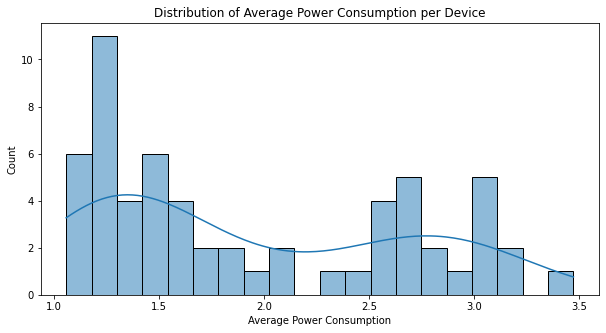

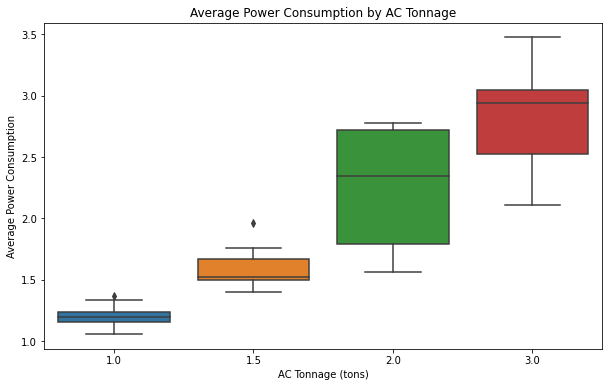

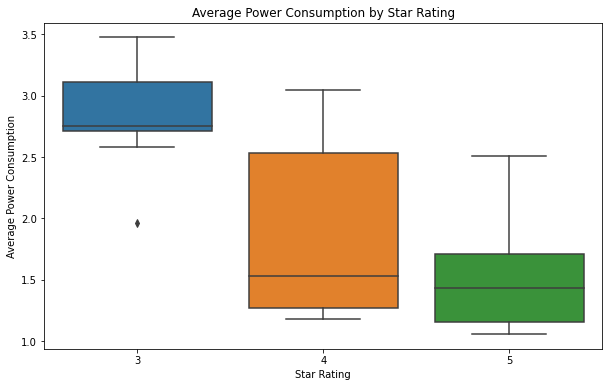

In [102]:
#Visualizations for device level consumption analysis

plt.figure(figsize=(10,5))
sns.histplot(device_profile['avg_power'], bins=20, kde=True)
plt.title("Distribution of Average Power Consumption per Device")
plt.xlabel("Average Power Consumption")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(10,6))
sns.boxplot(x='ac_tonnage', y='avg_power', data=device_profile)
plt.title("Average Power Consumption by AC Tonnage")
plt.xlabel("AC Tonnage (tons)")
plt.ylabel("Average Power Consumption")
plt.show()

plt.figure(figsize=(10,6))
sns.boxplot(x='star_rating', y='avg_power', data=device_profile)
plt.title("Average Power Consumption by Star Rating")
plt.xlabel("Star Rating")
plt.ylabel("Average Power Consumption")
plt.show()

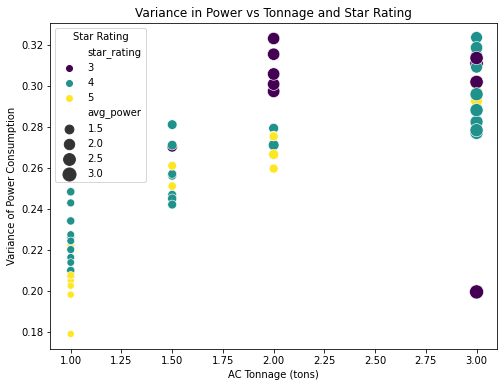

In [104]:
# Scatter plot for variance vs tonnage/star rating
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='ac_tonnage', y='var_power', hue='star_rating',
    size='avg_power', data=device_profile, palette='viridis', sizes=(50,200)
)
plt.title("Variance in Power vs Tonnage and Star Rating")
plt.xlabel("AC Tonnage (tons)")
plt.ylabel("Variance of Power Consumption")
plt.legend(title="Star Rating")
plt.show()

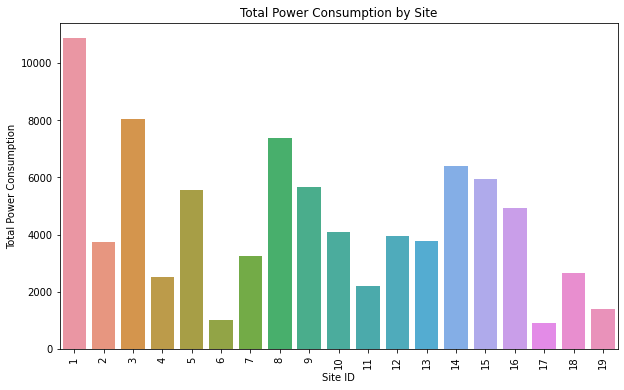

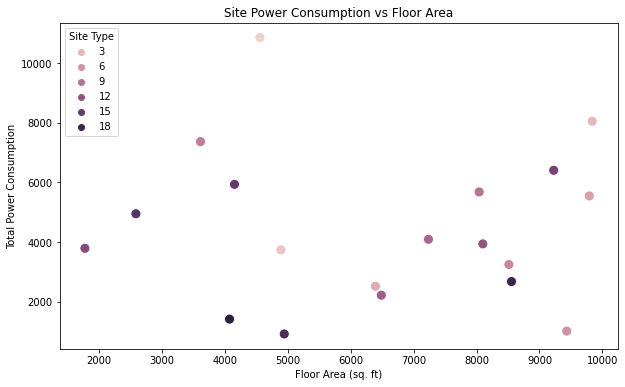

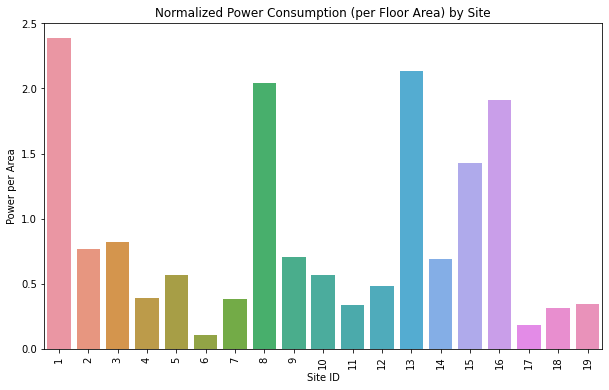

In [53]:
# Visualizations for site level consumption analysis

plt.figure(figsize=(10,6))
sns.barplot(x='site_id', y='total_power', data=site_profile.sort_values('total_power', ascending=False))
plt.title("Total Power Consumption by Site")
plt.xlabel("Site ID")
plt.ylabel("Total Power Consumption")
plt.xticks(rotation=90)
plt.show()

plt.figure(figsize=(10,6))
sns.scatterplot(x='floor_area', y='total_power', hue='site_id', data=site_profile, s=100)
plt.title("Site Power Consumption vs Floor Area")
plt.xlabel("Floor Area (sq. ft)")
plt.ylabel("Total Power Consumption")
plt.legend(title="Site Type")
plt.show()

plt.figure(figsize=(10,6))
sns.barplot(
    x='site_id', y='power_per_area',
    data=site_profile.sort_values('power_per_area', ascending=False)
)
plt.title("Normalized Power Consumption (per Floor Area) by Site")
plt.xlabel("Site ID")
plt.ylabel("Power per Area")
plt.xticks(rotation=90)
plt.show()

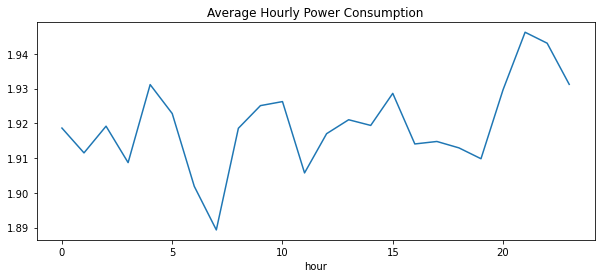

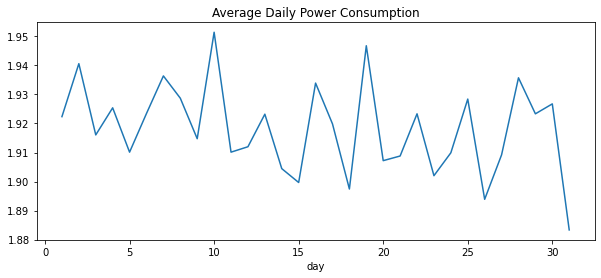

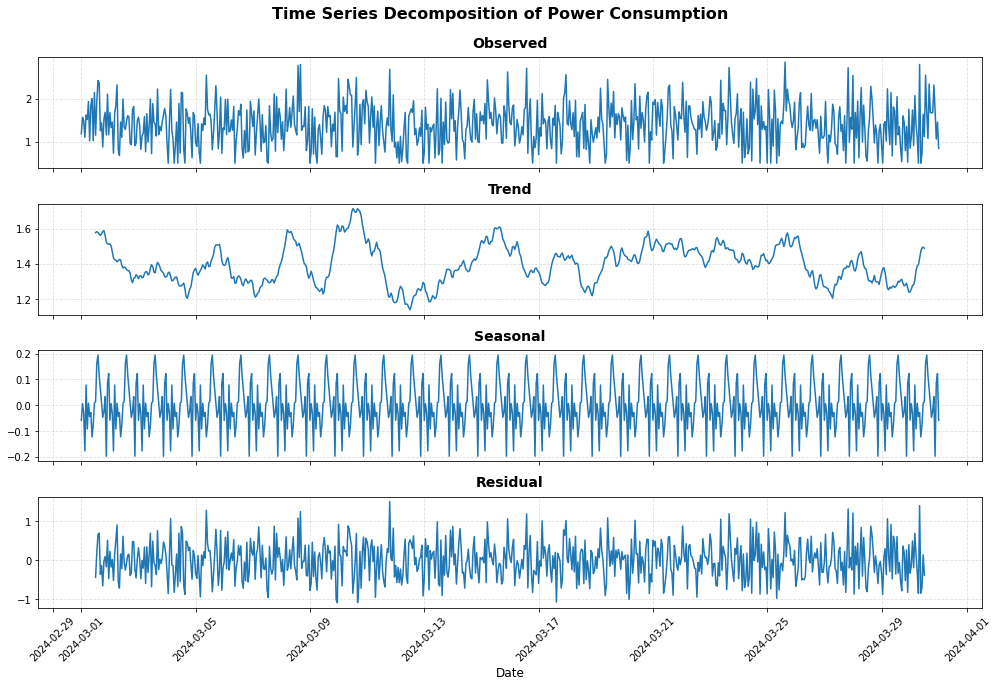

In [109]:
# Temporal Analysis
readings_clean['timestamp'] = pd.to_datetime(readings_clean['timestamp'])
readings_clean['hour'] = readings_clean['timestamp'].dt.hour
readings_clean['day'] = readings_clean['timestamp'].dt.day
readings_clean['weekday'] = readings_clean['timestamp'].dt.day_name()

hourly_avg = readings_clean.groupby('hour')['power_consumption'].mean()
daily_avg = readings_clean.groupby('day')['power_consumption'].mean()

plt.figure(figsize=(10,4))
hourly_avg.plot(title='Average Hourly Power Consumption')
plt.show()

plt.figure(figsize=(10,4))
daily_avg.plot(title='Average Daily Power Consumption')
plt.show()

# Time series analysis
sample_device = readings_clean[readings_clean['device_id'] == readings_clean['device_id'].unique()[0]]
sample_device.set_index('timestamp', inplace=True)
sample_device = sample_device.resample('H').mean().interpolate()

decomposition = seasonal_decompose(
    sample_device['power_consumption'],
    model='additive',
    period=24
)

# Create a clean, larger figure
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

# Plot each component manually with styling
components = {
    'Observed': decomposition.observed,
    'Trend': decomposition.trend,
    'Seasonal': decomposition.seasonal,
    'Residual': decomposition.resid
}

for ax, (title, series) in zip(axes, components.items()):
    ax.plot(series, color='#1f77b4', linewidth=1.5)
    ax.set_title(title, fontsize=14, fontweight='bold', pad=10)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.tick_params(axis='x', rotation=45)

# Shared x-label and tight layout
plt.xlabel("Date", fontsize=12)
fig.suptitle("Time Series Decomposition of Power Consumption", fontsize=16, fontweight='bold', y=0.95)
plt.tight_layout(rect=[0, 0, 1, 0.96])

# Save and show
plt.show()

# Part3 : Anomaly Detection & Root Cause Analysis

In [96]:
# Anomaly detection using z score
mean_pc = readings['power_consumption'].mean()
std_pc = readings['power_consumption'].std(ddof=0)
readings_clean['z_score'] = 0 if std_pc == 0 else abs((readings['power_consumption'] - mean_pc) / std_pc)

anomalies = readings[readings['z_score'] > 3].copy()  # copy to avoid SettingWithCopy

# Grouping anomalies into categories
if not anomalies.empty:
    anomalies['temp_diff'] = (anomalies['room_temp'] - anomalies['setpoint']).abs()
    anomalies['category'] = 'Sudden spike/drop'  # default category

    # thresholds
    high_power = readings['power_consumption'].quantile(0.95)
    low_power = readings['power_consumption'].quantile(0.25)

    cond1 = (anomalies['power_consumption'] > high_power) & (anomalies['temp_diff'] < 1)
    cond2 = (anomalies['temp_diff'] > 3) & (anomalies['power_consumption'] < low_power)

    anomalies.loc[cond1, 'category'] = 'High power, low temp diff'
    anomalies.loc[cond2, 'category'] = 'Low cooling, high power'

    # Ranking anomalies by severity
    anomalies['severity_rank'] = anomalies['z_score'].rank(method='dense', ascending=False).astype(int)

    print("Top anomalies by severity:")
    display(anomalies[['timestamp', 'device_id', 'power_consumption', 'z_score', 'category', 'severity_rank']].head(10))

    # Possible Root cause hints
    root_cause_summary = (
        anomalies.groupby('device_id')['category']
        .value_counts()
        .unstack(fill_value=0)
        .reset_index()
    )

    print("Anomaly category counts per device:")
    display(root_cause_summary.head())

else:
    print("No anomalies detected (z-score > 3).")

Top anomalies by severity:


,timestamp,device_id,power_consumption,z_score,category,severity_rank
8990,2024-03-15 02:00:00,13,5.326224,3.675945,"High power, low temp diff",5
9279,2024-03-27 03:00:00,13,4.721991,3.018203,"High power, low temp diff",85
18094,2024-03-03 21:00:00,26,5.039004,3.363290,Sudden spike/drop,28
19516,2024-03-03 01:00:00,28,4.729958,3.026875,"High power, low temp diff",83
19574,2024-03-05 11:00:00,28,5.378868,3.733251,"High power, low temp diff",3
19858,2024-03-17 07:00:00,28,4.867033,3.176089,Sudden spike/drop,55
19901,2024-03-19 02:00:00,28,5.047022,3.372018,Sudden spike/drop,27
19973,2024-03-22 02:00:00,28,4.770325,3.070817,"High power, low temp diff",72
19975,2024-03-22 04:00:00,28,4.875464,3.185267,"High power, low temp diff",51
20114,2024-03-27 23:00:00,28,4.962250,3.279739,Sudden spike/drop,40


Anomaly category counts per device:


category,device_id,"High power, low temp diff",Sudden spike/drop
0,13,2,0
1,26,0,1
2,28,4,4
3,29,2,1
4,36,36,30


#### Note: If we use the readings data with outliers removed/treated, there are no anomalies left in our data and the above code will return "No anomalies detected". In order to demonstrate anomaly detection, I've used the dataset with outliers.

# Part 4: Correlation & Causal Insights

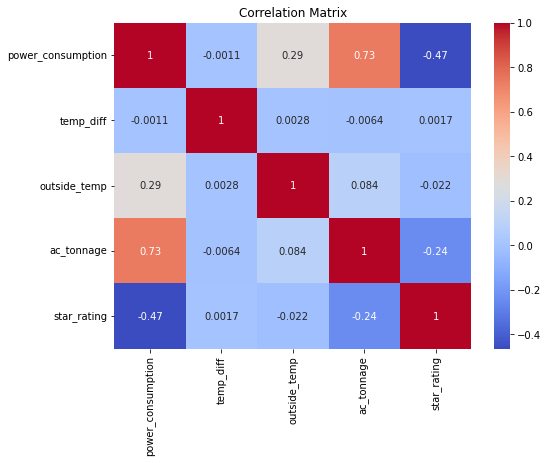


Correlation of power consumption with key factors:
power_consumption    1.000000
ac_tonnage           0.734239
outside_temp         0.289515
temp_diff           -0.001140
star_rating         -0.465246
Name: power_consumption, dtype: float64

Insight: Power consumption scales strongly with AC tonnage — larger units need more power.
Insight: Higher star ratings (efficiency) reduce power usage.


In [98]:
# Deriving variables
readings_clean['temp_diff'] = readings_clean['room_temp'] - readings_clean['setpoint']

# Mergeing with device info
merged = readings_clean.merge(devices, on='device_id', how='left')
merged_final = merged.rename(columns={'ac_tonnage_x': 'ac_tonnage', 'star_rating_x': 'star_rating'})

# Correlation matrix
corr_matrix = merged_final[['power_consumption', 'temp_diff', 'outside_temp', 'ac_tonnage', 'star_rating']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# Interpretation
corr_summary = corr_matrix['power_consumption'].sort_values(ascending=False)
print("\nCorrelation of power consumption with key factors:")
print(corr_summary)

# Suggested Operational Insights
if corr_summary['ac_tonnage'] > 0.5:
    print("\nInsight: Power consumption scales strongly with AC tonnage — larger units need more power.")
if corr_summary['star_rating'] < -0.3:
    print("Insight: Higher star ratings (efficiency) reduce power usage.")
if corr_summary['temp_diff'] > 0.4:
    print("Insight: Higher room-setpoint temperature gaps increase consumption — consider tighter control.")
if corr_summary['outside_temp'] > 0.3:
    print("Insight: Warmer ambient conditions drive higher consumption — schedule load balancing.")